In [1]:
# Cell 1 — Install
!pip install transformers torch pillow requests -q


In [2]:
# Cell 2 — Mount Drive + Setup
from google.colab import drive
drive.mount("/content/drive")

import os, torch, requests, textwrap
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
from transformers import BlipProcessor, BlipForConditionalGeneration

SAVE_DIR  = "/content/drive/MyDrive/MuseumCaption"
DEMO_DIR  = f"{SAVE_DIR}/demo_results"
os.makedirs(DEMO_DIR, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Results will be saved to: {DEMO_DIR}")

Mounted at /content/drive
GPU: NVIDIA A100-SXM4-40GB
Results will be saved to: /content/drive/MyDrive/MuseumCaption/demo_results


In [3]:
# Cell 3 — Load BLIP from Drive Cache
BLIP_PATH = f"{SAVE_DIR}/blip_model"

if os.path.exists(BLIP_PATH):
    print("Loading BLIP from Drive cache...")
    processor = BlipProcessor.from_pretrained(BLIP_PATH)
    model     = BlipForConditionalGeneration.from_pretrained(BLIP_PATH).to(device)
else:
    print("Downloading BLIP (first time only)...")
    processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
    model     = BlipForConditionalGeneration.from_pretrained(
                    "Salesforce/blip-image-captioning-base").to(device)
    processor.save_pretrained(BLIP_PATH)
    model.save_pretrained(BLIP_PATH)

model.eval()
print("✓ BLIP ready.")

Loading BLIP from Drive cache...


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✓ BLIP ready.


In [4]:
# Cell 4 — Caption Generator
def caption_image(img, beam_width=5):
    inputs = processor(images=img, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=50,
            min_new_tokens=8,
            num_beams=beam_width,
            no_repeat_ngram_size=3,
            length_penalty=1.5,
        )
    return processor.decode(out[0], skip_special_tokens=True)


In [5]:
# Cell 5 — Display Helper
def show_result(img, caption, title="MuseumCaption"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                              gridspec_kw={"width_ratios": [1, 1.3]})

    # Image
    axes[0].imshow(img)
    axes[0].axis("off")
    axes[0].set_title("Input Image", fontsize=13, fontweight="bold", pad=10)

    # Caption panel
    axes[1].axis("off")
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1)
    axes[1].add_patch(plt.Rectangle((0.03, 0.1), 0.94, 0.8,
                                     facecolor="#e6ffe6", edgecolor="#4CAF50",
                                     linewidth=2))
    axes[1].text(0.5, 0.75, "Generated Caption",
                 ha="center", va="center", fontsize=11,
                 fontweight="bold", color="#2e7d32")
    axes[1].text(0.5, 0.45,
                 "\n".join(textwrap.wrap(caption, width=32)),
                 ha="center", va="center", fontsize=13,
                 linespacing=1.9, color="#1a1a1a")
    axes[1].text(0.5, 0.18, "Model: BLIP (Salesforce)",
                 ha="center", va="center", fontsize=9,
                 color="#888", style="italic")

    plt.suptitle(f"MuseumCaption — {title}",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.subplots_adjust(left=0.02, right=0.98, wspace=0.05)

    # Save
    save_name = title.replace(" ", "_").replace("'", "")
    save_path = f"{DEMO_DIR}/{save_name}.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Saved: {save_path}")
    return save_path

╔══════════════════════════════════════════════╗
║       MuseumCaption — Live Demo              ║
║       BLIP Image Captioning System           ║
╚══════════════════════════════════════════════╝

Enter '1' to upload image OR '2' to paste URL: 1

📁 Choose your image file:


Saving IMG_9729.jpeg to IMG_9729.jpeg

📝 Caption: a bouquet of red roses and white flowers on a table


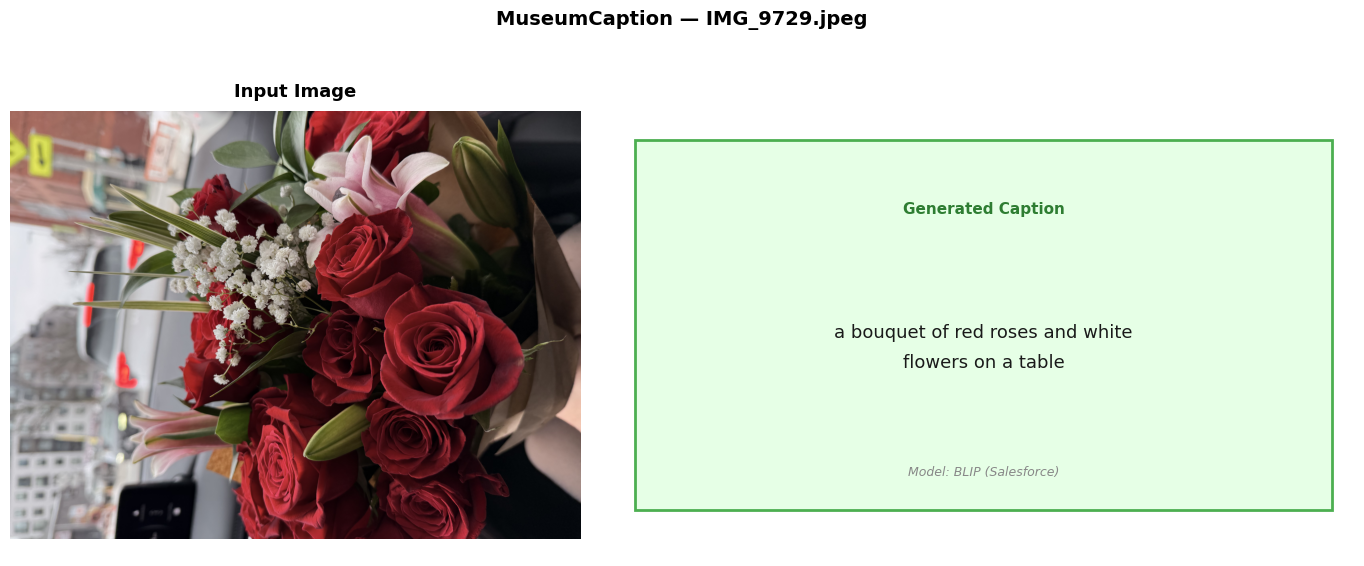

✓ Saved: /content/drive/MyDrive/MuseumCaption/demo_results/IMG_9729.jpeg.png


In [11]:
# Cell 7 — Run Both Options Together (cleanest for live demo)
print("╔══════════════════════════════════════════════╗")
print("║       MuseumCaption — Live Demo              ║")
print("║       BLIP Image Captioning System           ║")
print("╚══════════════════════════════════════════════╝\n")

choice = input("Enter '1' to upload image OR '2' to paste URL: ").strip()

if choice == "1":
    print("\n📁 Choose your image file:")
    uploaded = files.upload()
    for img_name, img_bytes in uploaded.items():
        img     = Image.open(BytesIO(img_bytes)).convert("RGB")
        caption = caption_image(img)
        print(f"\n📝 Caption: {caption}")
        show_result(img, caption, title=img_name)

elif choice == "2":
    url = input("Paste image URL: ").strip()
    try:
        headers  = {"User-Agent": "Mozilla/5.0"}
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status()
        img      = Image.open(BytesIO(response.content)).convert("RGB")
        caption  = caption_image(img)
        print(f"\n📝 Caption: {caption}")
        show_result(img, caption, title="URL_Image")
    except Exception as e:
        print(f"❌ Error: {e}")
else:
    print("Invalid choice. Please enter 1 or 2.")